# 🤖 Project 8 – Agentic Customer Analytics Assistant  
## Notebook 02 – Modeling: Return Prediction

In this notebook we:

- Load the cleaned customer analytics dataset  
- Prepare features and target for modeling  
- Train baseline models to predict `OrderReturn`  
- Evaluate model performance  
- Save the best model as a reusable pipeline for the agent

In [1]:
import os, sys
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# --- project paths & src package ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

from src.features import add_engineered_features

PROJECT_ROOT, DATA_DIR, MODELS_DIR

('C:\\Users\\ynalq\\Projects\\Data-portfolio\\project8-agentic-customer-analytics-assistant',
 'C:\\Users\\ynalq\\Projects\\Data-portfolio\\project8-agentic-customer-analytics-assistant\\data',
 'C:\\Users\\ynalq\\Projects\\Data-portfolio\\project8-agentic-customer-analytics-assistant\\models')

In [2]:
# load the clean data from notebook1
clean_path = os.path.join(DATA_DIR, "customer_analytics_clean.csv")
df = pd.read_csv(clean_path)

# Add engineered features (Recency, Frequency, CLV, CategoryReturnRate, ReturnFlag, etc.)
df = add_engineered_features(df)

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   SessionStart           2000 non-null   datetime64[ns]
 1   CustomerID             2000 non-null   int64         
 2   FullName               2000 non-null   object        
 3   Gender                 2000 non-null   object        
 4   Age                    2000 non-null   int64         
 5   CreditScore            2000 non-null   int64         
 6   MonthlyIncome          2000 non-null   int64         
 7   Country                2000 non-null   object        
 8   State                  2000 non-null   object        
 9   City                   2000 non-null   object        
 10  Category               2000 non-null   object        
 11  Product                2000 non-null   object        
 12  Cost                   2000 non-null   int64         
 13  Pri

In [3]:
# define target and inspect it
target_col = "OrderReturn"

# Keep only rows with True/False (remove NaN)
df = df[df[target_col].isin([True, False])].copy()

# Map to binary 0/1
df[target_col] = df[target_col].map({False: 0, True: 1}).astype(int)

df[target_col].value_counts(), df[target_col].value_counts(normalize=True)

(OrderReturn
 0    1464
 1     236
 Name: count, dtype: int64,
 OrderReturn
 0    0.861176
 1    0.138824
 Name: proportion, dtype: float64)

In [4]:
# choose features (X) and drop columns we won't use (yet)
drop_cols = [
    "FullName",
    "ReturnReason",
    "SessionStart",
    "SessionEnd",
    "CartAdditionTime",
    "OrderConfirmationTime",
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

X.head(), y.head()

(   CustomerID  Gender  Age  CreditScore  MonthlyIncome Country      State        City     Category    Product  Cost  \
 0        1001    Male   57          780           7591   China  Guangdong    Dongguan  electronics  table fan    30   
 1        1002  Female   69          746           3912   China   Shandong      Yantai      fashion      dress    50   
 2        1003  Female   21          772           7460      UK    England  Birmingham         toys  plush toy    12   
 3        1004  Female   67          631           4765      UK    England  Birmingham         toys  plush toy    12   
 4        1005    Male   57          630           3268   China   Shandong      Yantai      fashion      shoes    60   
 
    Price  Quantity     CampaignSchema  OrderConfirmation     PaymentMethod  Revenue  Margin  Recency  Frequency  \
 0     50         4      Instagram-ads               True  Cash On Delivery      200      80     1825          2   
 1     80         6         Google-ads        

In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((1360, 24), (340, 24))

In [6]:
# Preprocessor (encoding + scaling)
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [7]:
# XGBoost
# Compute imbalance ratio
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos
scale_pos_weight

6.195767195767195

In [8]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

In [9]:
# xgb_pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb)
])

In [10]:
# train
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# evaluate 
y_pred = xgb_pipeline.predict(X_test)
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

#from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 0.8176470588235294
XGBoost ROC-AUC: 0.49560670975237814

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       293
           1       0.06      0.02      0.03        47

    accuracy                           0.82       340
   macro avg       0.46      0.48      0.47       340
weighted avg       0.75      0.82      0.78       340



In [12]:
# preprocessing + baseline logistic regression model 
log_reg = LogisticRegression(max_iter=1000)

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

log_reg_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
# Train & Evaluate logistic regression
log_reg_pipeline.fit(X_train, y_train)

y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("LogReg Accuracy:", accuracy_score(y_test, y_pred))
print("LogReg ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

LogReg Accuracy: 0.861764705882353
LogReg ROC-AUC: 0.4330114007697335

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       293
           1       0.00      0.00      0.00        47

    accuracy                           0.86       340
   macro avg       0.43      0.50      0.46       340
weighted avg       0.74      0.86      0.80       340



C:\Users\ynalq\anaconda3\envs\data-portfolio\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ynalq\anaconda3\envs\data-portfolio\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ynalq\anaconda3\envs\data-portfolio\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

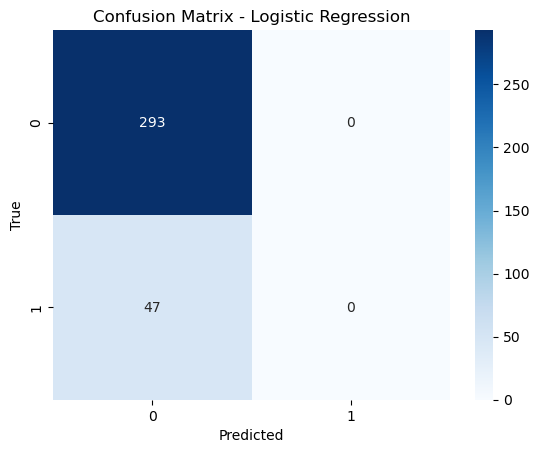

In [14]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [15]:
# RandomForest model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report (RF):")
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.861764705882353
RF ROC-AUC: 0.5035945102025997

Classification Report (RF):
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       293
           1       0.00      0.00      0.00        47

    accuracy                           0.86       340
   macro avg       0.43      0.50      0.46       340
weighted avg       0.74      0.86      0.80       340



C:\Users\ynalq\anaconda3\envs\data-portfolio\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ynalq\anaconda3\envs\data-portfolio\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ynalq\anaconda3\envs\data-portfolio\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [16]:
# save the best model pipeline
best_model = rf_pipeline   
model_path = os.path.join(MODELS_DIR, "order_return_model.pkl")

joblib.dump(best_model, model_path)
model_path

'C:\\Users\\ynalq\\Projects\\Data-portfolio\\project8-agentic-customer-analytics-assistant\\models\\order_return_model.pkl'